# Modelling the Day Ahead Electricity Prices via a Multiple Regression Model and Residuals via an Ornstein Uhlenbeck Model
## The strategy is supposed to create N by 24 matrix of scenarios

In [1]:
# Importing Libraries

In [2]:
import sys
sys.path.append('../')
import pandas as pd
import numpy as np
from diagnostic_test import Diagnostics
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from transformations import transform_prices, inverse_transform
import warnings


warnings.filterwarnings("ignore")
pd.set_option('mode.use_inf_as_na', True)
plt.style.use("grayscale")

In [3]:
# init instance of diagnostics
diagnostics = Diagnostics()

In [4]:
prices = pd.read_csv("../data/prices.csv", index_col=1).iloc[:,1:]
rl_f = pd.read_csv("../data/rl.csv", index_col=1).iloc[:,1:]

In [5]:
prices.index = pd.to_datetime(prices.index)
rl_f.index = pd.to_datetime(rl_f.index)

In [6]:
prices = prices[~prices.index.duplicated(keep='last')]
rl_f = rl_f[~rl_f.index.duplicated(keep='last')]

In [7]:
prices.head(), rl_f.head()

(                     DA_price  ID3_price
 delivery_begin                          
 2023-01-01 00:00:00     -1.46      -3.70
 2023-01-01 01:00:00     -1.52      -5.07
 2023-01-01 02:00:00     -5.00     -25.95
 2023-01-01 03:00:00     -4.60      -5.76
 2023-01-01 04:00:00     -4.05      -5.57,
                               rl
 delivery_begin                  
 2023-01-02 00:00:00  9544.869048
 2023-01-02 01:00:00  8992.847789
 2023-01-02 02:00:00  8435.429842
 2023-01-02 03:00:00  8056.250706
 2023-01-02 04:00:00  7629.176972)

# Data Cleaning
## Linear interpolation to fill missing value and outlier detection and replacement

In [8]:
# Linear Interpolation to fill missing data
prices = prices.interpolate(method='linear')
rl_f = rl_f.interpolate(method='linear')

In [9]:
# outliers
# Step 1: Calculate the lower and upper percentiles
# Source: Paper: Short-term risk management for electricity retailers under rising shares of decentralized solar generation. Available at: https://www.econstor.eu/handle/10419/235576
lower_percentile = prices['DA_price'].quantile(0.025)
upper_percentile = prices['DA_price'].quantile(0.975)

# Step 2: Replace outliers
prices['DA_price'] = prices['DA_price'].clip(lower=lower_percentile, upper=upper_percentile)

# Step 1: Calculate the lower and upper percentiles
lower_percentile = rl_f.quantile(0.025)
upper_percentile = rl_f.quantile(0.975)

# Step 2: Replace outliers
rl_f = rl_f.clip(lower=lower_percentile, upper=upper_percentile, axis=1)

In [10]:
prices.head(), rl_f.head()

(                     DA_price  ID3_price
 delivery_begin                          
 2023-01-01 00:00:00  -1.46000      -3.70
 2023-01-01 01:00:00  -1.52000      -5.07
 2023-01-01 02:00:00  -4.97475     -25.95
 2023-01-01 03:00:00  -4.60000      -5.76
 2023-01-01 04:00:00  -4.05000      -5.57,
                               rl
 delivery_begin                  
 2023-01-02 00:00:00  9544.869048
 2023-01-02 01:00:00  8992.847789
 2023-01-02 02:00:00  8435.429842
 2023-01-02 03:00:00  8056.250706
 2023-01-02 04:00:00  7629.176972)

In [11]:
prices.shape, rl_f.shape

((15742, 2), (16054, 1))

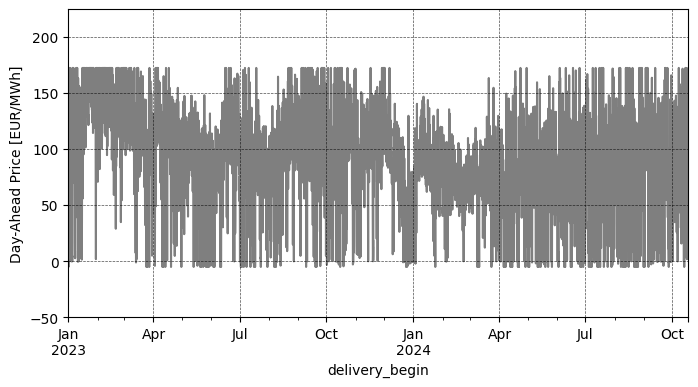

In [12]:
fig, ax = plt.subplots(figsize=(8, 4), facecolor="white")  # Ensures a white background
prices['DA_price'].plot(ax=ax, alpha=0.5, color="black")  # Set plot color explicitly to black

ax.set_ylabel("Day-Ahead Price [EUR/MWh]", fontsize=10)
ax.set_ylim(-50, 225)  # Adjust Y-axis limits for better visibility

ax.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

plt.show()


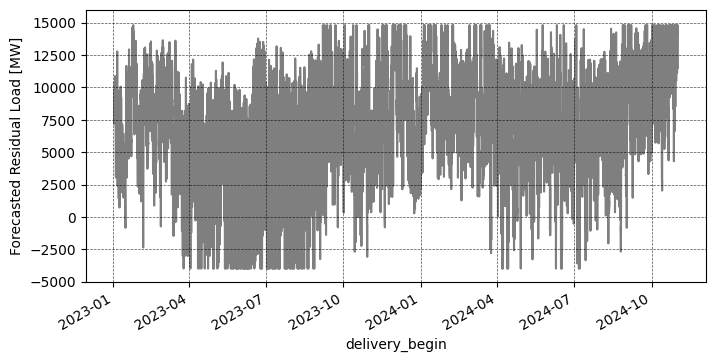

In [13]:
fig, ax = plt.subplots(figsize=(8, 4), facecolor="white")  # Ensure a white background
rl_f['rl'].plot(ax=ax, alpha=0.5, color="black")  # Use black for the line plot

ax.set_ylabel("Forecasted Residual Load [MW]", fontsize=10)
ax.set_ylim(-5000, 16000)  # Adjust Y-axis limits for better visibility
ax.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

plt.show()


## Transform Data to Area Hyperbolic Sine Transformation

In [14]:
# test sample index no
fro, to = -1006, -1006+24

In [15]:
# # training_window = len(prices.iloc[1:fro,:])
# transformed_da_prices, median_da_prices, mad_da_prices = transform_prices(prices['DA_price'], training_window)
# transformed_rl_f, median_rl_f, mad_rl_f = transform_prices(rl_f['rl'], training_window)

In [16]:
transformed_da_prices = prices['DA_price']
transformed_rl_f = rl_f

In [17]:
prices['DA_price'] = transformed_da_prices
rl_f['rl'] = transformed_rl_f

In [18]:
transformed_da_prices.dropna()

delivery_begin
2023-01-01 00:00:00     -1.46000
2023-01-01 01:00:00     -1.52000
2023-01-01 02:00:00     -4.97475
2023-01-01 03:00:00     -4.60000
2023-01-01 04:00:00     -4.05000
                         ...    
2024-10-17 17:00:00    171.00000
2024-10-17 18:00:00    117.50000
2024-10-17 19:00:00    100.00000
2024-10-17 20:00:00     97.00000
2024-10-17 21:00:00     88.40000
Name: DA_price, Length: 15742, dtype: float64

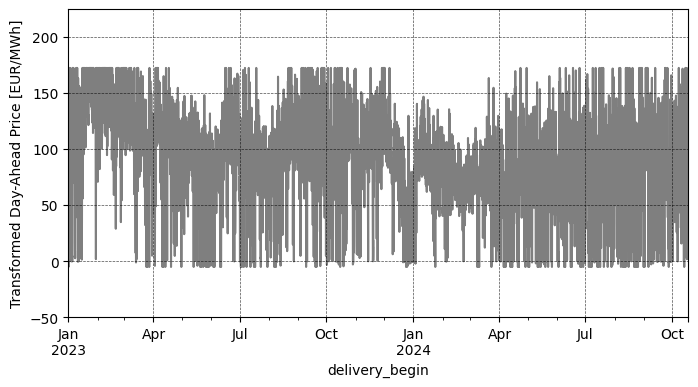

In [19]:
fig, ax = plt.subplots(figsize=(8, 4), facecolor="white")  # Ensures a white background
transformed_da_prices.plot(ax=ax, alpha=0.5, color="black")  # Use black for the plot line

ax.set_ylabel("Transformed Day-Ahead Price [EUR/MWh]", fontsize=10)
ax.set_ylim(-50, 225)  # Adjust Y-axis limits for better visibility
ax.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

plt.show()


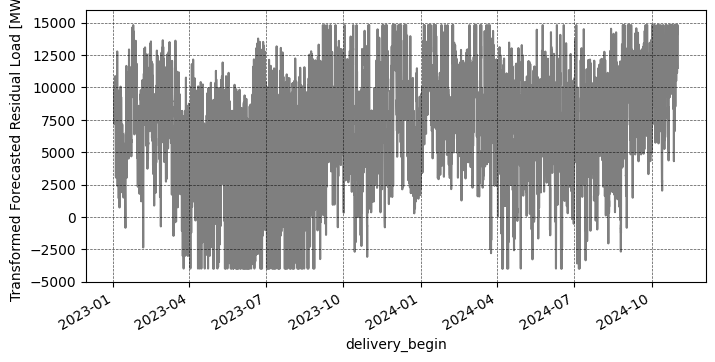

In [20]:
fig, ax = plt.subplots(figsize=(8, 4), facecolor="white")  # Ensure a white background
transformed_rl_f['rl'].plot(ax=ax, alpha=0.5, color="black")  # Use black for the plot line

ax.set_ylabel("Transformed Forecasted Residual Load [MW]", fontsize=10)
ax.set_ylim(-5000, 16000)  # Adjust Y-axis limits for better visibility
ax.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

plt.show()


In [21]:
# merge Day-Ahead data - prices and rl_f
da_data = pd.merge(prices['DA_price'], rl_f['rl'], on='delivery_begin')

# Creating Indicators

## Weekend dummy

In [22]:
# Step 1: Create a 'weekend' column, where 1 represents Saturday or Sunday and 0 represents other days
da_data['weekend'] = da_data.index.weekday >= 5  # Saturday=5, Sunday=6

# Step 2: Convert the boolean 'weekend' column to integers (0 and 1)
da_data['weekend'] = da_data['weekend'].astype(int)

## Rolling min / max price for the previous day

In [23]:
# create min and max for prices
da_data['price_min'] = da_data['DA_price'].shift(24).rolling(24).min() 
da_data['price_max'] = da_data['DA_price'].shift(24).rolling(24).max()

## Average 24 hourly price & RL for the previous day

In [24]:
# # average 24 hour prices
# da_data['DA_price_24'] = da_data['DA_price'].shift(24).rolling(24).mean() 
# da_data['rl_f_24'] = rl_f.shift(24).rolling(24).mean()

## Last known price - i.e. this is the price at 23:00 previous day

In [25]:
# last price
shifted_index = da_data.index - pd.Timedelta(days=1)
shifted_index = shifted_index.normalize() + pd.Timedelta(hours=23)

# Map the shifted index to the 'price' column to get the previous day's 23:00 price
da_data['last_price'] = da_data['DA_price'].reindex(shifted_index).values

## last of the previous day, prev to prev day and last week at same hour for DA Price

In [26]:
# # Step 3: Create lagged variables for DA_price
da_data[f'DA_price_lag_24'] = da_data['DA_price'].shift(24)
da_data[f'DA_price_lag_48'] = da_data['DA_price'].shift(48)
da_data[f'DA_price_lag_168'] = da_data['DA_price'].shift(168)

## Modular Hourly Cycle

In [27]:
# Step 1: Extract hour from timestamp and calculate mean price for each hour
da_data["hour"] = da_data.index.hour
hourly_means = da_data.iloc[:to,:].groupby("hour")["DA_price"].mean()

# Step 2: Map the hourly means back to the original data
da_data["p_DA_bar"] = da_data["hour"].map(hourly_means)

# Step 3: Incorporate the modular operation explicitly (t mod 24)
da_data["hour_mod"] = da_data.index.hour % 24  # This is equivalent to .dt.hour
da_data["p_DA_modular"] = da_data["hour_mod"].map(hourly_means).shift(24)

# Verify
da_data["p_DA_modular"]
da_data.drop(columns=['hour_mod', 'hour', 'p_DA_bar'], inplace=True)

## RL forecast of current period, previous day, prev to prev day and last week at same hour

In [28]:
# # Step 3: Create lagged variables for rl
# for lag in range(0, 1):  # Creating lags for DA_price (up to 3 lags)
#     da_data[f'rl_lag_{lag}'] = da_data['rl'].shift(lag) 

# last day same hour
da_data[f'rl_lag_0'] = da_data['rl'] 
da_data[f'rl_lag_24'] = da_data['rl'].shift(24)
da_data[f'rl_lag_48'] = da_data['rl'].shift(48)
da_data[f'rl_lag_168'] = da_data['rl'].shift(168)


## Some quadratic & interaction terms

In [29]:
# da_data[f'1_1'] = da_data['rl'].shift(24) ** 2
# da_data[f'2_2'] = da_data['rl'] ** 2
# da_data[f'3_3'] = da_data['DA_price'].shift(24) - da_data['DA_price'].shift(168)

## Preparing X and y train and test sets

In [30]:
da_data.dropna(inplace=True)

In [31]:
da_data.head()

,DA_price,rl,weekend,price_min,price_max,last_price,DA_price_lag_24,DA_price_lag_48,DA_price_lag_168,p_DA_modular,rl_lag_0,rl_lag_24,rl_lag_48,rl_lag_168
delivery_begin,,,,,,,,,,,,,,
2023-01-09 00:00:00,64.38,3892.398939,0,9.07,112.87,75.13,9.07,98.16,94.90,75.868339,3892.398939,2693.112094,5061.926989,9544.869048
2023-01-09 01:00:00,60.28,3857.844869,0,9.07,112.87,75.13,9.10,94.96,52.93,72.717419,3857.844869,2278.690535,4273.502980,8992.847789
2023-01-09 02:00:00,39.41,4287.268391,0,3.46,112.87,75.13,3.46,83.86,44.16,71.146512,4287.268391,2124.853381,3734.392947,8435.429842
2023-01-09 03:00:00,43.12,4627.584472,0,2.80,112.87,75.13,2.80,76.66,50.08,74.127330,4627.584472,2215.781265,3317.048213,8056.250706
2023-01-09 04:00:00,69.07,4785.717777,0,2.80,112.87,75.13,5.08,69.88,77.09,84.620709,4785.717777,2335.530237,3092.863796,7629.176972


In [32]:
fro, to = -1006, -1006+24

In [33]:
# defining train and test data
X_train = da_data.iloc[:to,2:] 
X_test = da_data.iloc[fro:to,2:]

y_train = da_data.iloc[:to, 0]
y_test  = da_data.iloc[fro:to, 0]

In [34]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((14566, 12), (24, 12), (14566,), (24,))

## Factor correlation heat map to detect multicollinearity

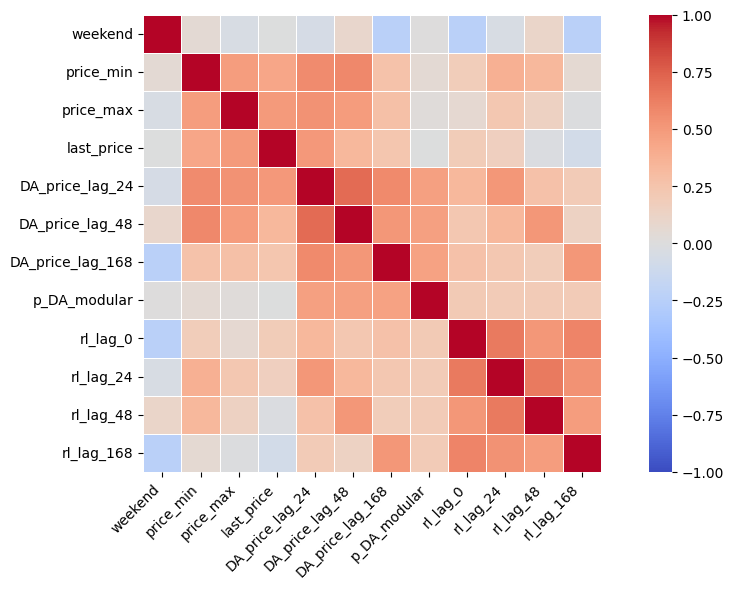

In [35]:
# Compute the correlation matrix
corr_matrix = X_train.corr()

# Create the heatmap with improved formatting
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")  # Increase figure size

sns.heatmap(corr_matrix, 
            cmap="coolwarm", 
            vmin=-1, vmax=1, 
            annot=False, 
            linewidths=0.5, 
            cbar=True, 
            square=True, 
            ax=ax)

# Adjust tick labels
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate x labels for better visibility
plt.yticks(rotation=0, fontsize=10)  # Ensure y labels are readable

# Adjust layout to prevent clipping
plt.tight_layout()

# Save the heatmap
plt.savefig('../images/DA/da_heatmap.png', dpi=300, bbox_inches='tight')  # Ensure everything fits

# Show the heatmap
plt.show()


## Model training with constant

In [36]:
# Fit Model
# Add a constant to the model (intercept)
X_train = sm.add_constant(X_train)

model = sm.OLS(y_train, X_train).fit(cov_type='HC3')

# Step 5: Output the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               DA_price   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.784
Method:                 Least Squares   F-statistic:                     4498.
Date:                Sat, 26 Apr 2025   Prob (F-statistic):               0.00
Time:                        12:05:04   Log-Likelihood:                -64050.
No. Observations:               14566   AIC:                         1.281e+05
Df Residuals:                   14553   BIC:                         1.282e+05
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -13.5368      1.325  

## Model results & testing residuals

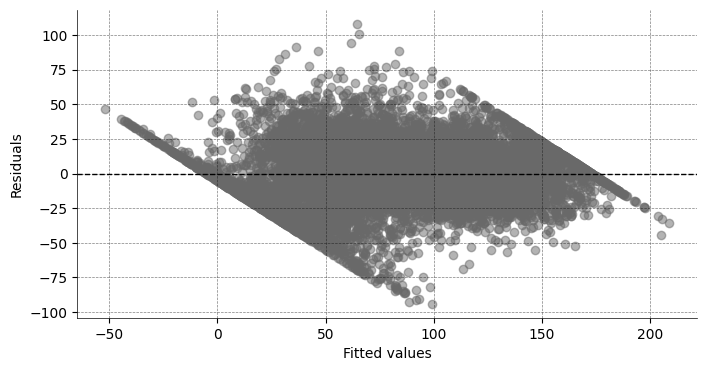

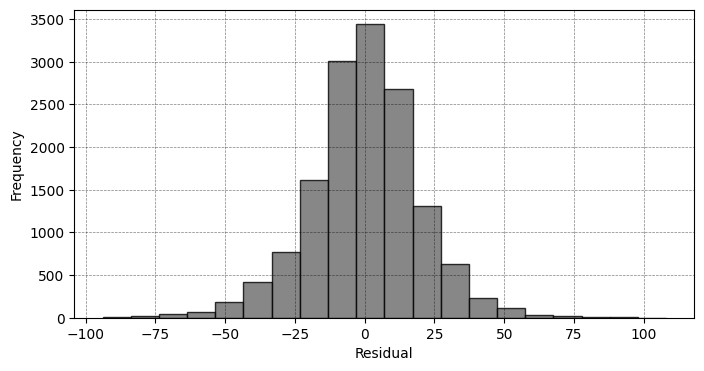

Durbin-Watson statistic: 0.3379345242054591
Autocorrelation detected in residuals.
Breusch-Pagan test statistic: 940.7881492989234, p-value: 9.012941764618289e-193
Heteroscedasticity detected.
Ljung-Box test p-values for autocorrelation:
         lb_stat  lb_pvalue
24  25692.575536        0.0
Autocorrelation detected in residuals.


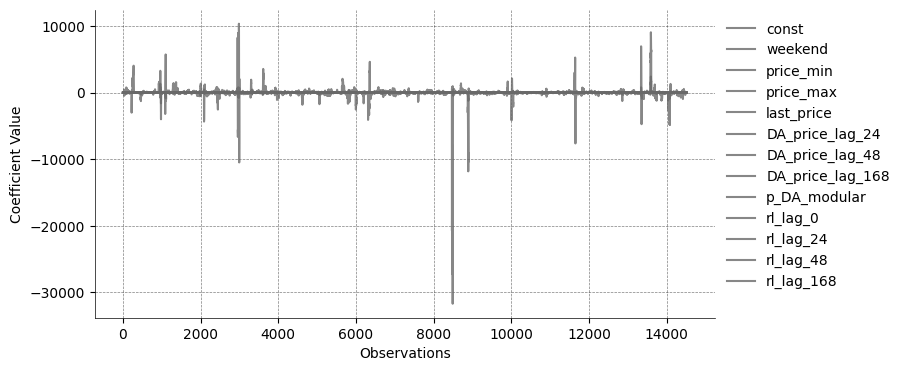

Model parameters show signs of instability.
Shapiro-Wilk Test:
Statistic: 0.9853, p-value: 0.0000
Residuals not normal.

Anderson-Darling Test:
Statistic: 47.3613
Significance Level: 15.0%, Critical Value: 0.5760
Significance Level: 10.0%, Critical Value: 0.6560
Significance Level: 5.0%, Critical Value: 0.7870
Significance Level: 2.5%, Critical Value: 0.9180
Significance Level: 1.0%, Critical Value: 1.0920


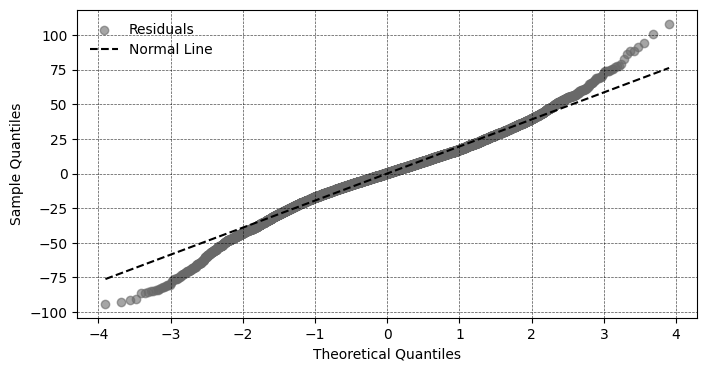

Variance Inflation Factors (VIF):
          VIF  Variable
0   63.362343         0
1    1.270731         1
2    2.063001         2
3    1.855877         3
4    1.857056         4
5    4.671655         5
6    4.365885         6
7    2.951867         7
8    1.900901         8
9    2.450251         9
10   3.577762        10
11   3.352653        11
12   3.090034        12
High multicollinearity detected in predictors.


,VIF,Variable
0,63.362343,0
1,1.270731,1
2,2.063001,2
3,1.855877,3
4,1.857056,4
5,4.671655,5
6,4.365885,6
7,2.951867,7
8,1.900901,8
9,2.450251,9


In [37]:
residuals = model.resid
fig, ax = plt.subplots(figsize=(8, 4), facecolor="white")  # Ensure white background
ax.scatter(model.fittedvalues, residuals, color='dimgray', alpha=0.5)  # Greyish scatter points
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel("Fitted values", fontsize=10)
ax.set_ylabel("Residuals", fontsize=10)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

plt.savefig('../images/DA/da_resid_vs_fitted.png')
plt.show()

# Residuals vs Fitted values
diagnostics.plot_histogram(residuals, title='', path='../images/DA/da_lm_hist.png')
diagnostics.durbin_watson_test(residuals)
diagnostics.breusch_pagan_test(residuals, model.model.exog)
diagnostics.ljung_box_test(residuals, lags=24)
diagnostics.rolling_window_stability(model, window_size=50, path='../images/DA/da_lm_stability.png')
diagnostics.normality_test(residuals, path='../images/DA/da_lm_normality.png')
diagnostics.check_multicollinearity(model.model.exog)

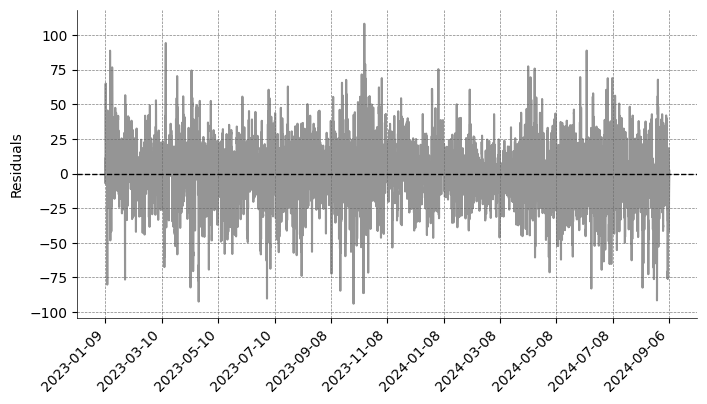

In [38]:
fig, ax = plt.subplots(figsize=(8, 4), facecolor="white")  # Ensure white background
ax.plot(residuals, color='dimgray', alpha=0.7)
ax.axhline(0, color='black', linestyle='--', linewidth=1)

ax.set_ylabel("Residuals", fontsize=10)
# ax.set_title("Residuals Over Time", fontsize=12, fontweight='bold')
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

# Formatting x-axis dates
if isinstance(residuals.index, pd.DatetimeIndex):
    ax.set_xticks(residuals.index[::len(residuals)//10])  # Show only a few ticks
    ax.set_xticklabels(residuals.index[::len(residuals)//10].strftime('%Y-%m-%d'), rotation=45, ha='right')

plt.savefig('../images/DA/da_lm_resid.png')
plt.show()


## predict the next 24 hourly intervals of Day-Ahead prices

In [39]:
X_test = sm.add_constant(X_test, has_constant='add')
X_forecast = model.predict(X_test)

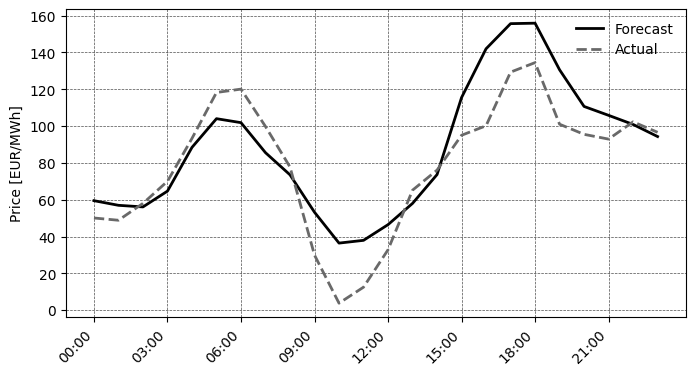

In [40]:
fig, ax = plt.subplots(figsize=(8, 4), facecolor="white")  # Ensure white background
ax.plot(X_forecast, color='black', linestyle='-', linewidth=2, label='Forecast')
ax.plot(da_data['DA_price'].iloc[fro:to], color='dimgray', linestyle='--', linewidth=2, label='Actual')

ax.set_ylabel("Price [EUR/MWh]", fontsize=10)
ax.legend(fontsize=10, frameon=False, loc="best")
ax.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

# Formatting x-axis to show only every 3 hours
if isinstance(da_data.index, pd.DatetimeIndex):
    three_hour_ticks = da_data.index[fro:to][da_data.index[fro:to].hour % 3 == 0]  # Select every 3rd hour
    ax.set_xticks(three_hour_ticks)
    ax.set_xticklabels(three_hour_ticks.strftime('%H:00'), rotation=45, ha='right')

plt.savefig('../images/DA/da_forecast_actual.png')
plt.show()


In [41]:
# Modelling the residuals via an OU-process.
# Source: Day-Ahead Electricty Price Forecasting during Periods of Increased Volatility. Available at: https://www.diva-portal.org/smash/get/diva2:1739566/FULLTEXT02

# Estimate OU parameters
mu = residuals.mean()
rho = residuals.autocorr(lag=2)
theta = -np.log(rho)
sigma = residuals.std()

# Simulation parameters
T = 24  # Total time (24 hours)
dt = 1  # Time step (1 hour)
n_scenarios = 1000  # Number of scenarios
n_steps = int(T / dt)

# Initialize array for scenarios
scenarios = np.zeros((n_scenarios, n_steps))

# Simulate scenarios
for i in range(n_scenarios):
    X = np.zeros(n_steps+1)
    X[0] = residuals.iloc[-1]  # Start from the last observed residual
    for t in range(1, n_steps+1):
        dW = np.random.normal(scale=np.sqrt(dt))
        X[t] = X[t-1] + theta * (mu - X[t-1]) * dt + sigma * dW
    scenarios[i, :] = X[1:]

# Ensure X_forecast has 24 values
if len(X_forecast) != 24:
    raise ValueError("X_forecast must have 24 hourly values.")

# Create 1000 scenario price paths
scenario_price_paths = scenarios + X_forecast.values

# Convert to DataFrame for easier handling
scenario_price_df = pd.DataFrame(scenario_price_paths, columns=[f'Hour_{i+1}' for i in range(24)])


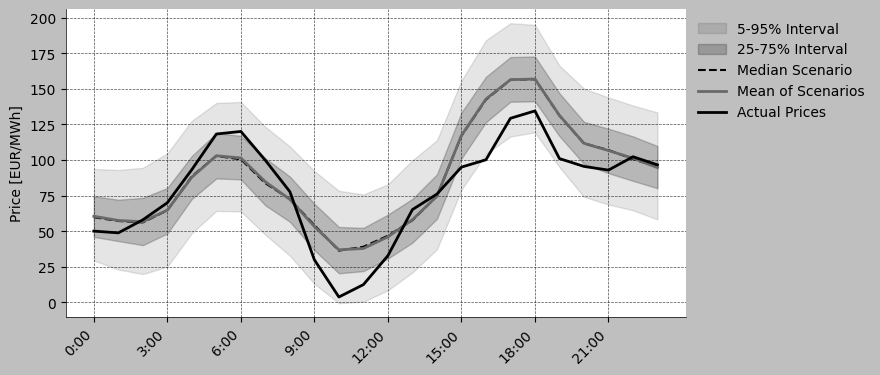

In [42]:
# Compute percentiles for shading
percentiles = [5, 25, 50, 75, 95]
percentile_values = np.percentile(scenario_price_paths, percentiles, axis=0)

# Extract actual prices for the given range
actual_prices = prices['DA_price'].iloc[fro:to].values

# Plotting with professional thesis-style formatting
fig, ax = plt.subplots(figsize=(8, 4))

# Shaded areas for percentile ranges
ax.fill_between(range(T), percentile_values[0], percentile_values[4], color='black', alpha=0.1, label='5-95% Interval')
ax.fill_between(range(T), percentile_values[1], percentile_values[3], color='black', alpha=0.2, label='25-75% Interval')

# Median and mean lines
ax.plot(range(T), percentile_values[2], color='black', linestyle='--', linewidth=1.5, label='Median Scenario')
ax.plot(range(T), scenario_price_df.mean(axis=0).values, color='dimgray', linestyle='-', linewidth=2, label='Mean of Scenarios')

# Actual prices
ax.plot(range(T), actual_prices, color='black', linewidth=2, label='Actual Prices')

# Labels, title, and legend
ax.set_ylabel("Price [EUR/MWh]", fontsize=10)

# Set x-axis ticks to show only every 3 hours
x_ticks = np.arange(0, T, 3)  # Generate tick positions at intervals of 3 hours
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{h}:00" for h in x_ticks], rotation=45, ha='right')

# Legend styling
ax.legend(fontsize=10, frameon=False, loc="best", bbox_to_anchor=(1, 1))

# Grid and axis formatting
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

# Display the plot
plt.show()


In [43]:
# Make some testing on the residual here!!!!!

## Fit an Ornstein-Uhlenbeck process to the residuals

Fitting an Ornstein-Uhlenbeck (OU) process to residuals that show inverse correlation with fitted values can improve the model by capturing mean-reverting behavior, thus reducing systematic biases. This process allows for scenario generation, adding a structured way to account for forecast uncertainty through simulated residual paths. By smoothing out patterns and reducing residual autocorrelation, the OU process helps transform residuals closer to white noise, mitigating temporal dependencies. Overall, incorporating OU-adjusted residuals can address model misspecifications, reducing inverse correlation with fitted values and yielding a more balanced and reliable forecast.

## N by 24 scenario building by OU process fit to residuals and adding back to deterministic model forecast

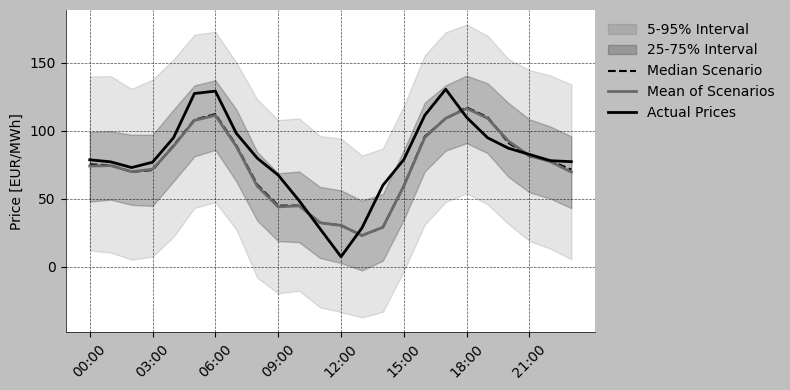

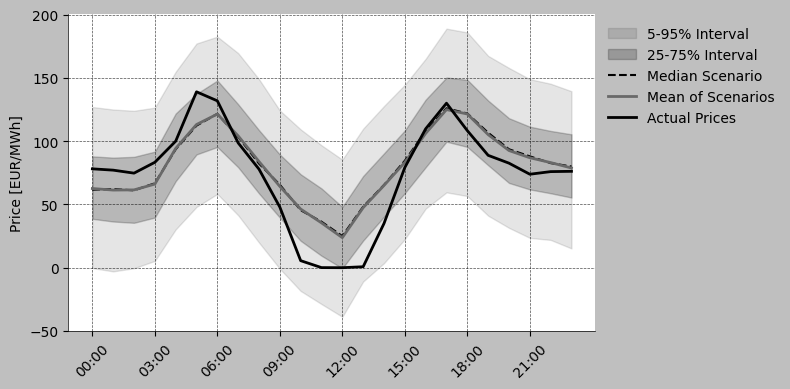

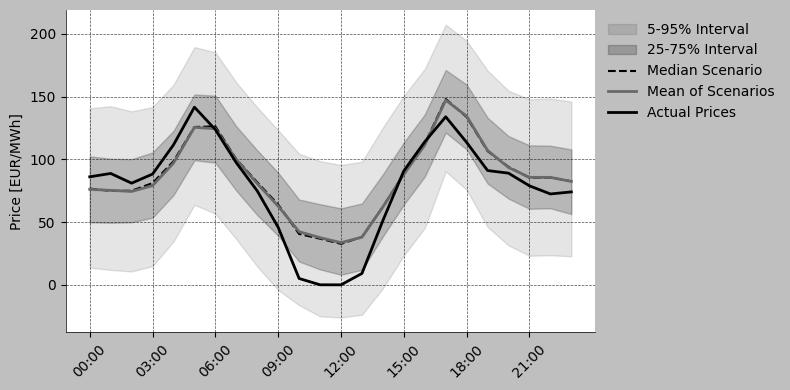

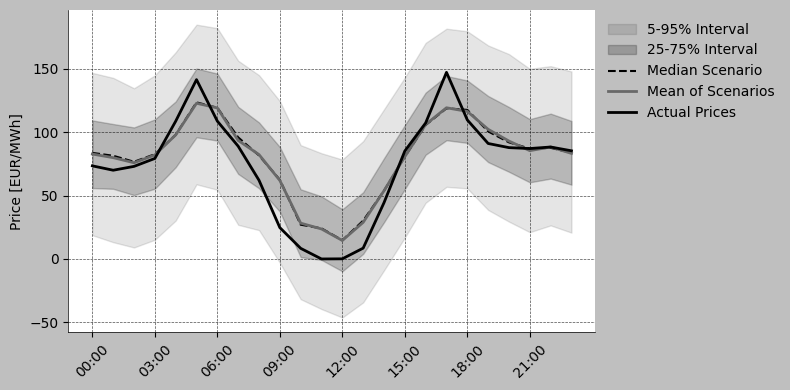

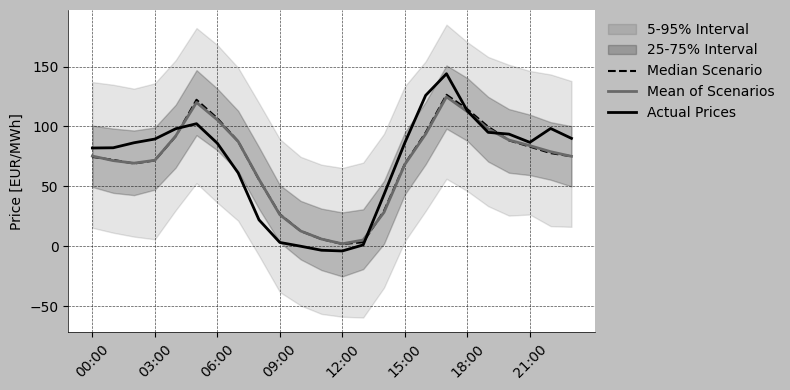

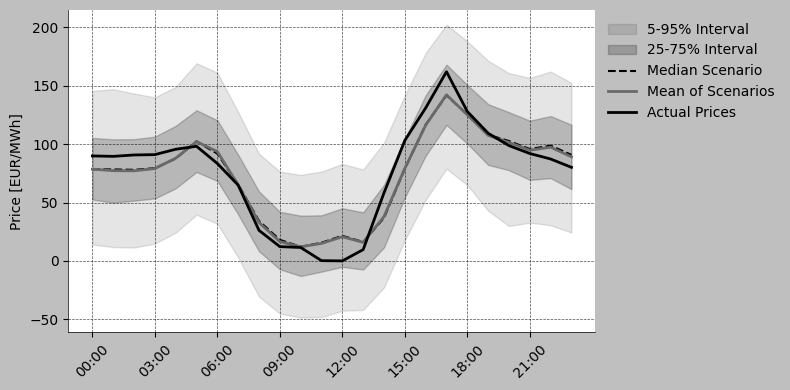

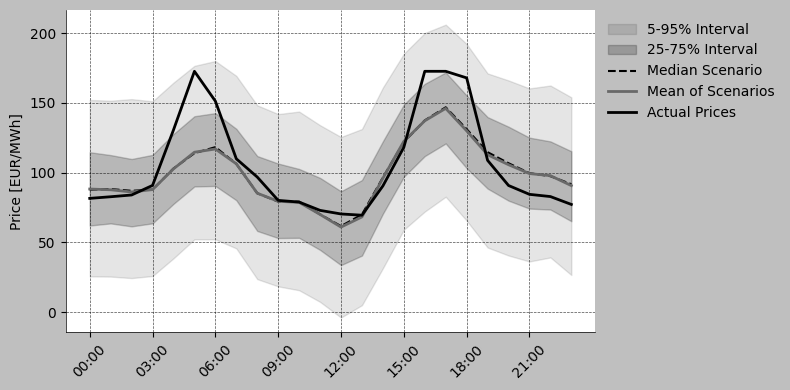

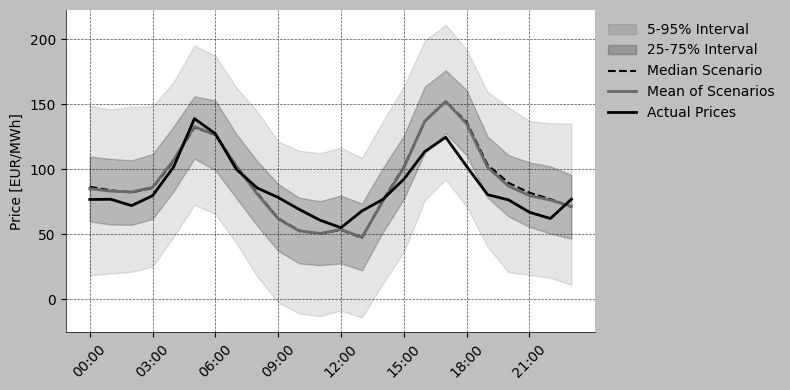

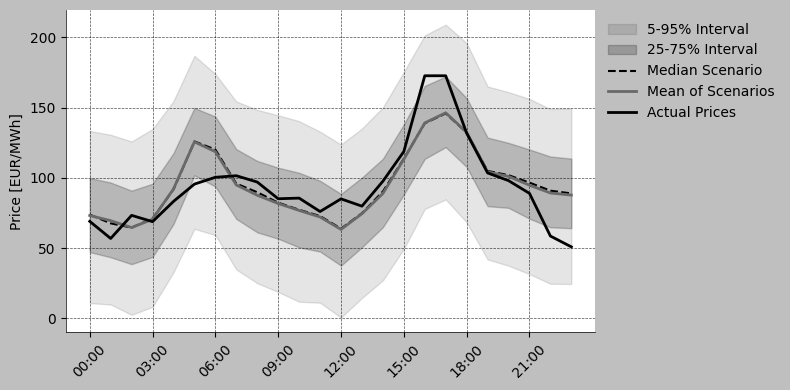

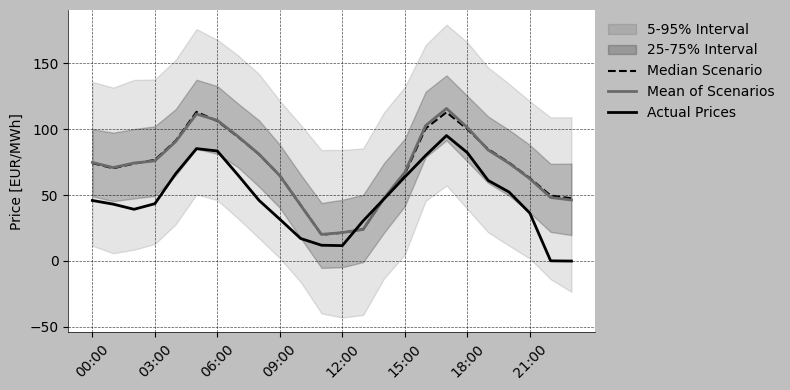

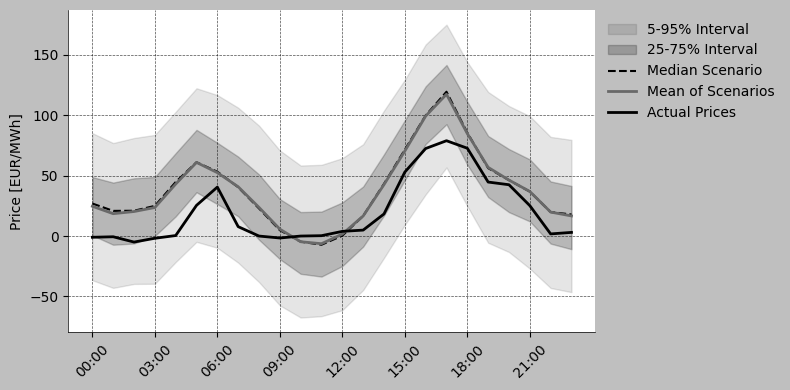

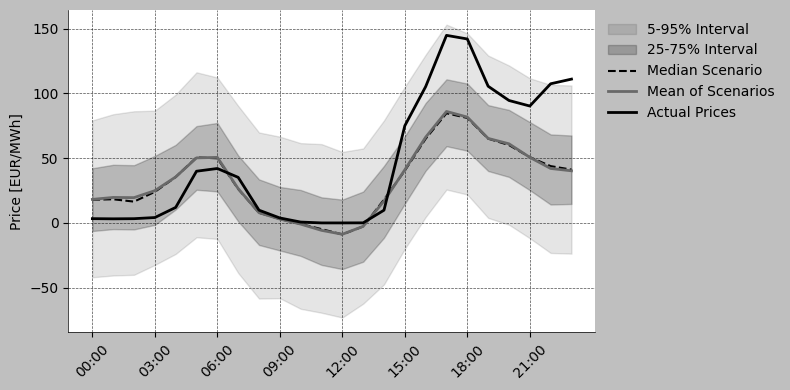

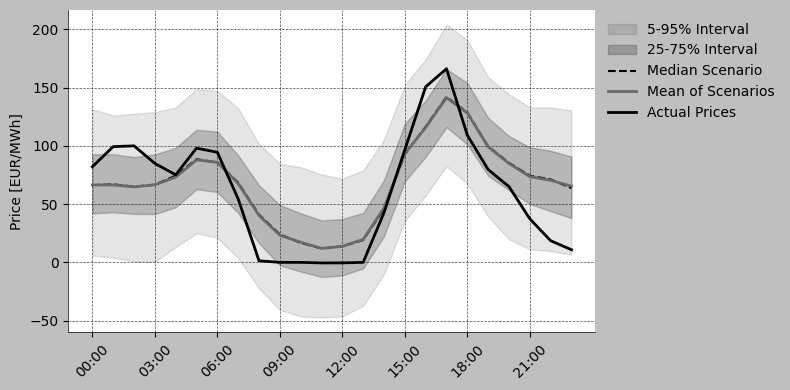

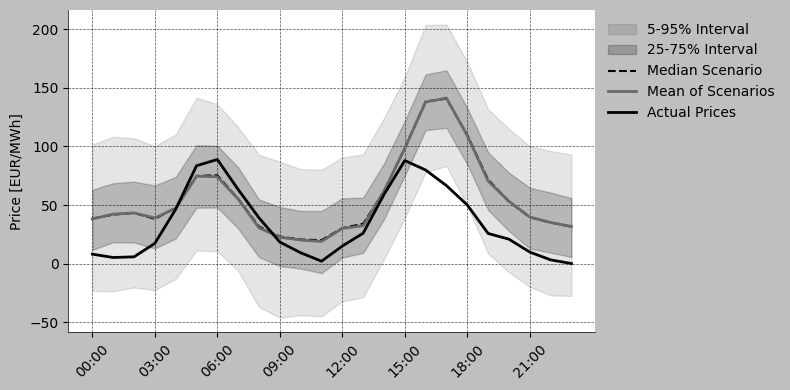

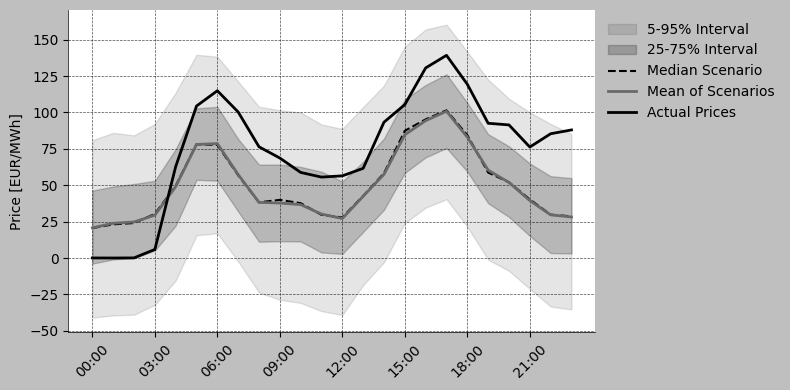

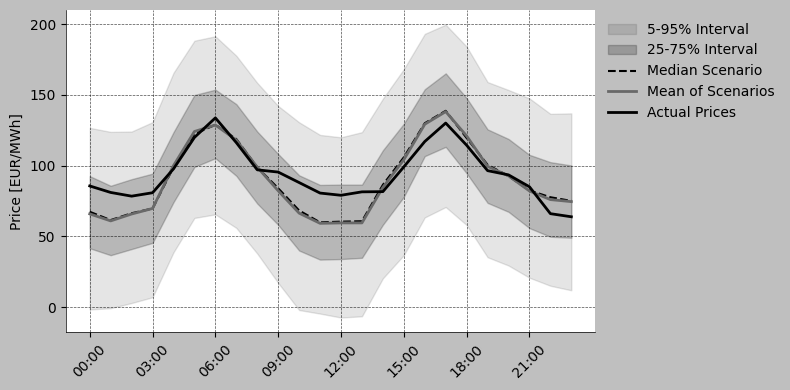

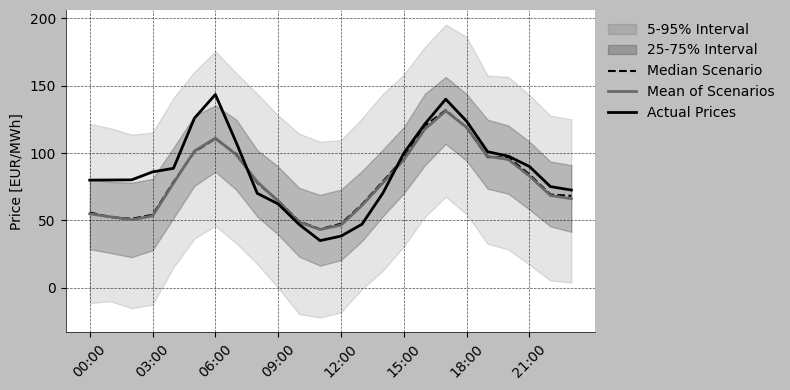

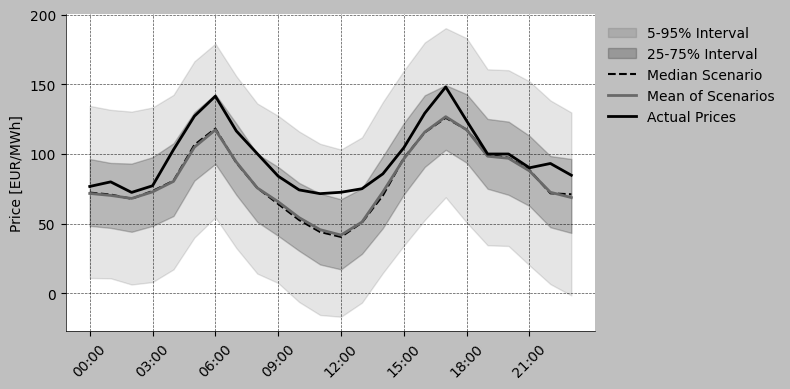

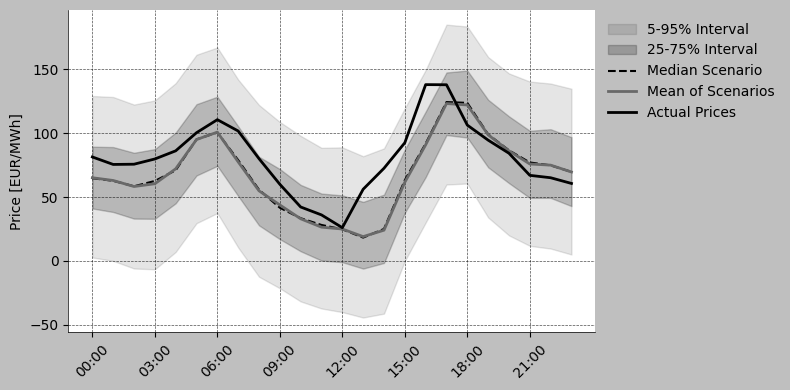

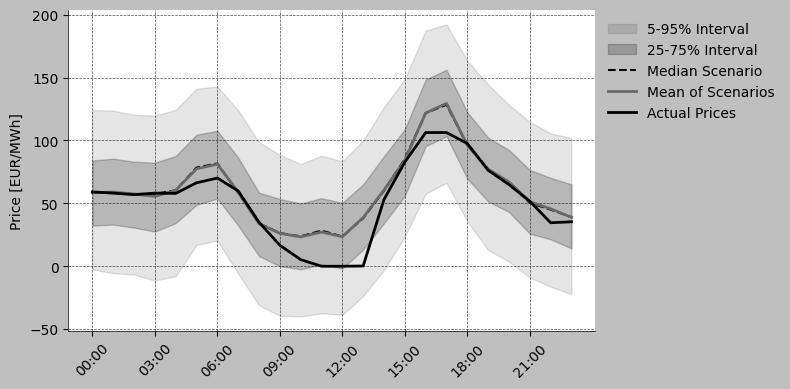

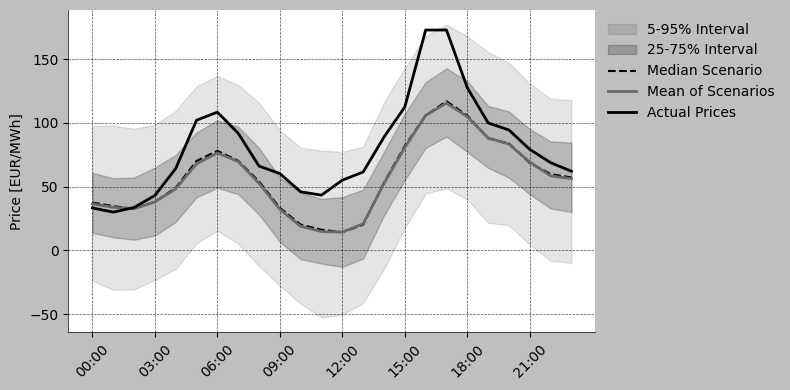

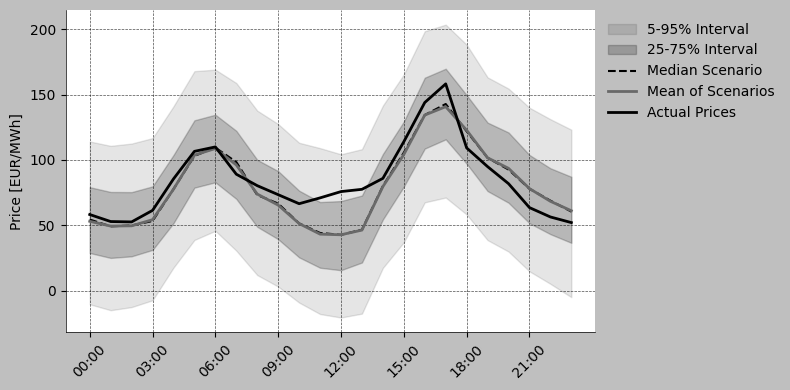

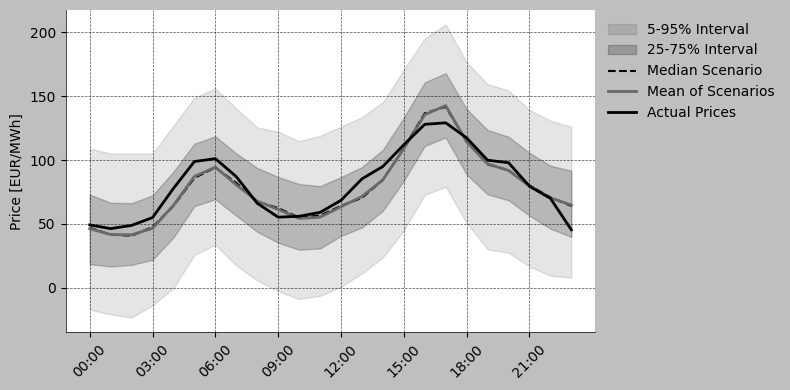

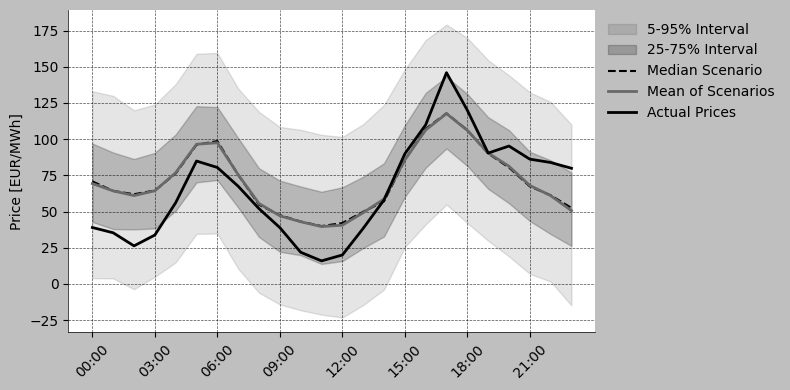

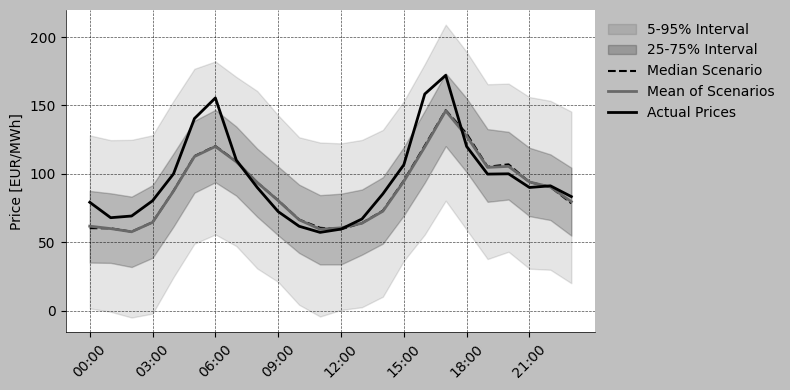

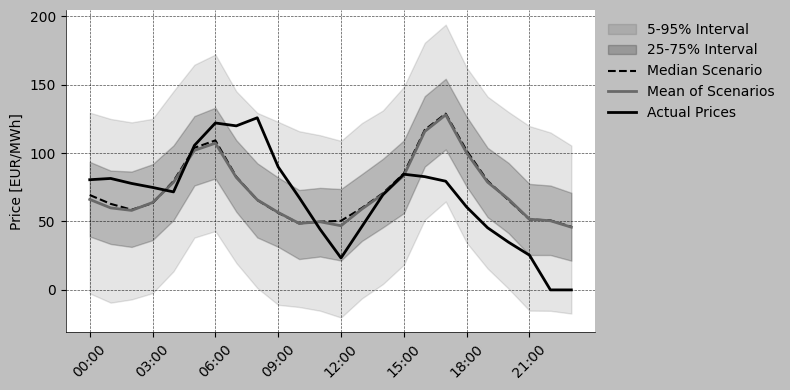

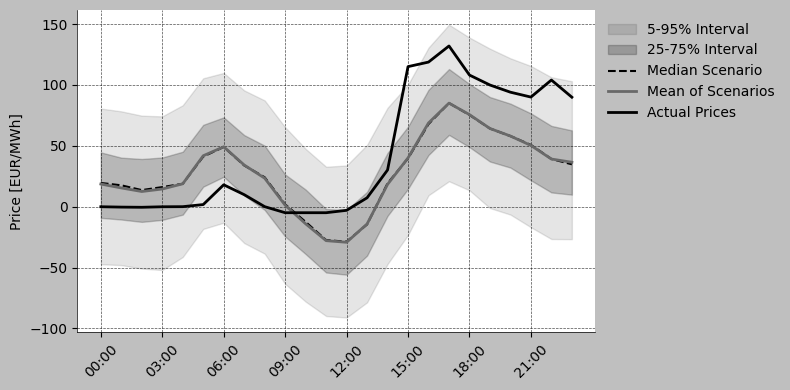

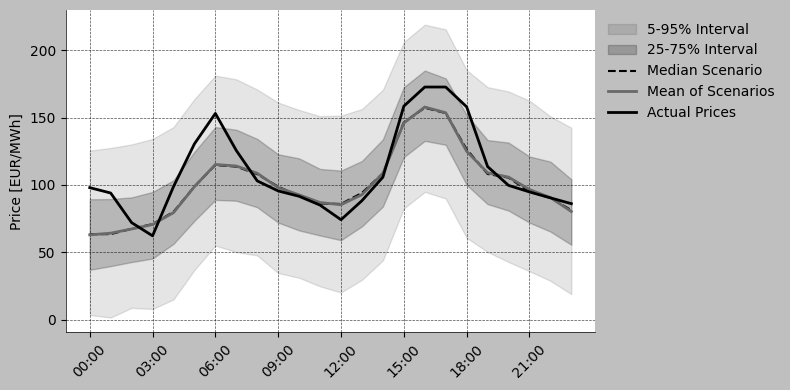

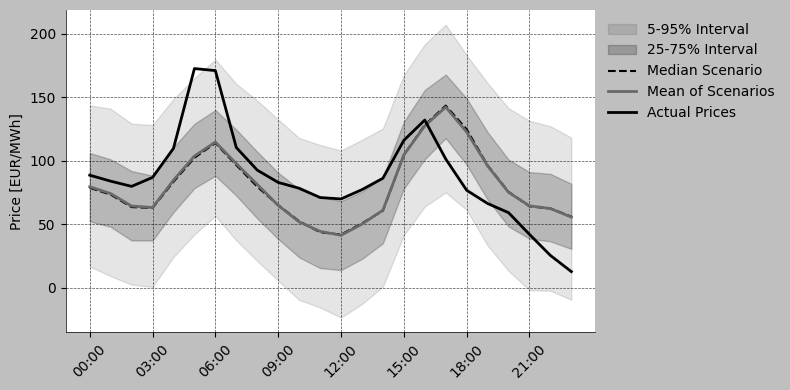

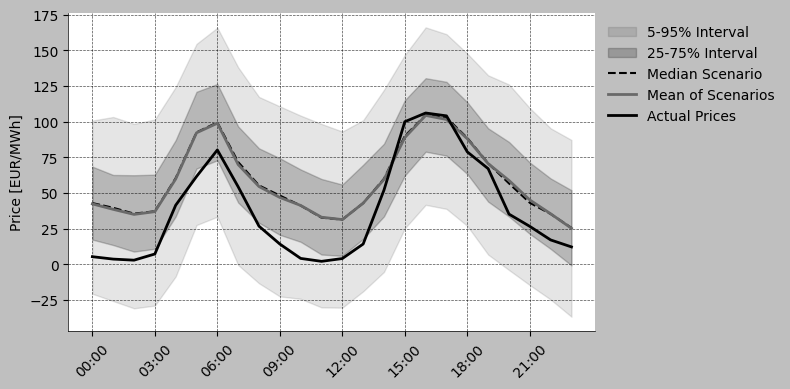

In [44]:
def rolling_forecast_with_burn_in(da_data, window_size=24, forecast_horizon=24, n_scenarios=1000, burn_in_days=28):
    """
    Perform a rolling forecast over the last month, moving 24 hours at a time, with a burn-in period.

    Parameters:
    - da_data: DataFrame with 'DA_price' and other features.
    - window_size: Historical window size for training (e.g., 24 hours).
    - forecast_horizon: Number of hours to forecast.
    - n_scenarios: Number of scenarios for the OU process.
    - burn_in_days: Number of days for the burn-in period.
    """
    end_idx = len(da_data) - forecast_horizon - 22
    start_idx = end_idx - 24 * 30  # Last 30 days (24 hours * 30)

    for i in range(start_idx, end_idx, forecast_horizon):
        # Define training and testing data
        X_train = da_data.iloc[:i + window_size, 1:]
        y_train = da_data.iloc[:i + window_size, 0]
        X_test = da_data.iloc[i + window_size:i + 2 * window_size, 1:]
        y_test = da_data.iloc[i + window_size:i + 2 * window_size, 0]

        # Fit OLS model
        X_train = sm.add_constant(X_train)
        model = sm.OLS(y_train, X_train).fit(cov_type='HC3')
        X_test = sm.add_constant(X_test, has_constant='add')
        X_forecast = model.predict(X_test)
        residuals = model.resid

        # OU Process Parameters
        dt = 1  # Time step (1 hour)
        mu = residuals.mean()
        rho = residuals.autocorr(lag=1)
        theta = -np.log(rho) / dt
        sigma = residuals.std() * np.sqrt(2 * theta / (1 - rho**2))

        # Jump Parameters
        threshold = 3 * sigma
        jumps = residuals[np.abs(residuals - mu) > threshold]
        lambda_ = len(jumps) / len(residuals)
        mu_J = jumps.mean() - mu
        sigma_J = jumps.std()

        # Burn-in period calculation
        burn_in_hours = burn_in_days * 24
        T = burn_in_hours + forecast_horizon

        # Scenario Generation
        scenarios = np.zeros((n_scenarios, forecast_horizon))
        for scenario in range(n_scenarios):
            X = np.zeros(T)
            X[0] = np.random.choice(residuals)
            for t in range(1, T):
                dW = np.random.normal(scale=np.sqrt(dt))
                jump = np.random.normal(mu_J, sigma_J) if np.random.rand() < lambda_ * dt else 0
                X[t] = X[t-1] + theta * (mu - X[t-1]) * dt + sigma * dW + jump
            scenarios[scenario, :] = X[-forecast_horizon:]

        # Combine forecast with scenarios
        scenario_price_paths = scenarios + X_forecast.values
        scenario_price_df = pd.DataFrame(scenario_price_paths, columns=[f'Hour_{j+1}' for j in range(forecast_horizon)])

        # Save scenarios
        scenario_price_df.to_csv(f"../scenarios/da/ARIMAX_{str(y_test.index[0])[:10]}.csv")
        y_test.to_csv(f"../scenarios/da/prices_{str(y_test.index[0])[:10]}.csv")

        # Compute percentiles for shading
        percentiles = [5, 25, 50, 75, 95]
        percentile_values = np.percentile(scenario_price_paths, percentiles, axis=0)

        # Plot with professional grayscale formatting
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.fill_between(y_test.index, percentile_values[0], percentile_values[4], color='black', alpha=0.1, label='5-95% Interval')
        ax.fill_between(y_test.index, percentile_values[1], percentile_values[3], color='black', alpha=0.2, label='25-75% Interval')

        ax.plot(y_test.index, percentile_values[2], color='black', linestyle='--', linewidth=1.5, label='Median Scenario')
        ax.plot(y_test.index, scenario_price_df.mean(axis=0).values, color='dimgray', linestyle='-', linewidth=2, label='Mean of Scenarios')
        ax.plot(y_test.index, y_test.values, color='black', linewidth=2, label='Actual Prices')

        # Labels and title
        ax.set_ylabel("Price [EUR/MWh]", fontsize=10)

        # Set x-ticks every 3 hours
        ax.set_xticks(y_test.index[::3])
        ax.set_xticklabels(y_test.index[::3].strftime('%H:%M'), rotation=45)

        # Legend styling
        ax.legend(fontsize=10, frameon=False, loc="best", bbox_to_anchor=(1, 1))

        # Grid and axis formatting
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(0.5)
        ax.spines["bottom"].set_linewidth(0.5)

        # Adjust tick formatting
        plt.tight_layout()
        plt.savefig(f'../images/DA/forecasts/da_price_scenarios_{str(y_test.index[0])[:10]}.png')
        plt.show()

# Execute rolling forecast with burn-in (assuming da_data is defined)
rolling_forecast_with_burn_in(da_data=da_data, n_scenarios=1000, burn_in_days=28)
